In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

import warnings
warnings.filterwarnings('ignore')


In [5]:
!pip install matplotlib seaborn scikit-learn torchvision



  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/104.6 kB ? eta -:--:--
     -------------------------------------- 104.6/104.6 kB 5.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 3.2 MB/s eta 0:00:00
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.2/8.1 MB 7.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/8.1 MB 7.6 MB/s eta 0:00:01
   ----- ---------------------------------- 1.0/8.1 MB 8.0 MB/s eta 0:00:01
   ------- -------------------------------- 1.5/8.1 MB 8.5 MB/s eta 0:00:01
   --------- ------------------------------ 2.0/8.1 MB 8.9 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.1 MB


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install --upgrade pip


  Using cached pip-25.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-25.0.1-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
D:\NNDL\dl_env\Scripts\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))


CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


Classes : ['Bio-degradable', 'Electronic', 'Medical', 'Nonbio-degradable', 'Recyclable']

Train counts: {'Bio-degradable': 12518, 'Electronic': 3016, 'Medical': 1568, 'Nonbio-degradable': 7528, 'Recyclable': 10143}
Test  counts: {'Bio-degradable': 1277, 'Electronic': 628, 'Medical': 454, 'Nonbio-degradable': 2188, 'Recyclable': 1590}


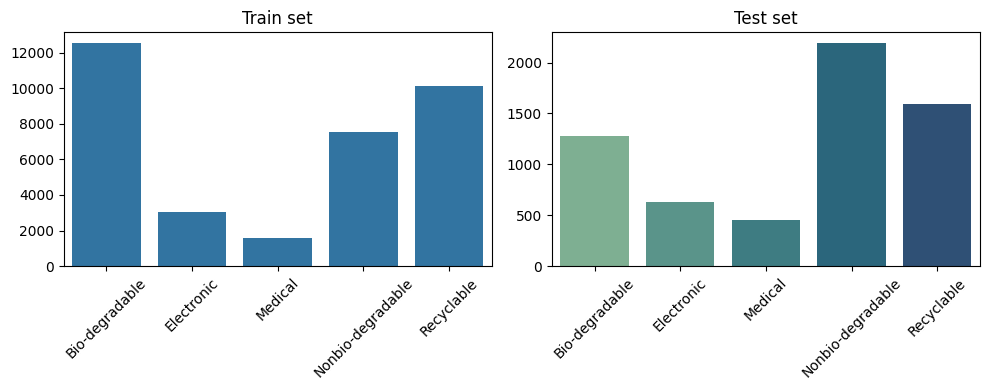

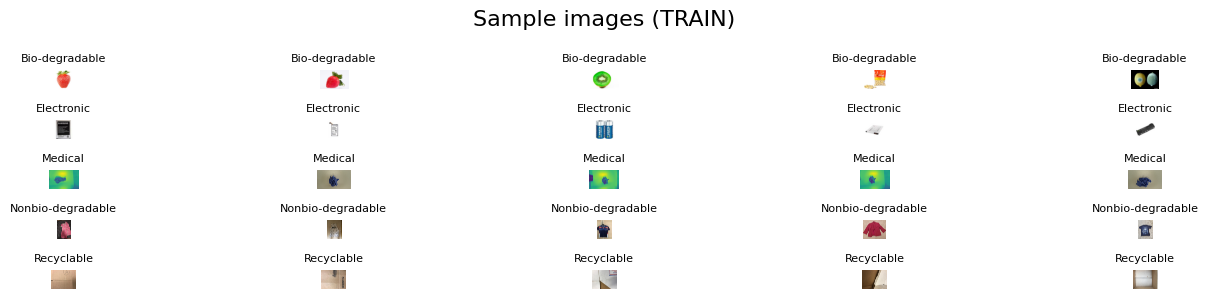


Average resolution: 315.8 × 272.4


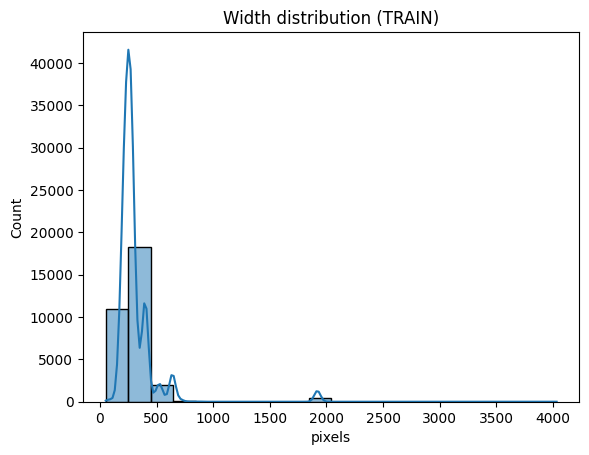

In [2]:
# 1‑A  IMPORTS  ────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from itertools import islice
from pathlib import Path

# accepted image extensions
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

# 1‑C  FUNCTION: count images per class in a folder
def iter_images(folder: Path):
    """Yield Path objects for all images under 'folder', recursively."""
    for p in folder.rglob("*"):
        if p.suffix.lower() in IMG_EXTS and p.is_file():
            yield p

def count_per_class_recursive(root_dir):
    counts = {}
    for cls_dir in sorted(Path(root_dir).iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = sum(1 for _ in iter_images(cls_dir))
    return counts

# 1‑B  PATHS  ──────────────────────────────────────────
DATA_ROOT = r"D:\NNDL\Dataset\DATASET"        # ← change if different
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
TEST_DIR  = os.path.join(DATA_ROOT, "TEST")

train_counts = count_per_class_recursive(TRAIN_DIR)
test_counts  = count_per_class_recursive(TEST_DIR)

# 1‑D  PRINT BASIC STATS
print("Classes :", list(train_counts.keys()))
print("\nTrain counts:", train_counts)
print("Test  counts:", test_counts)

# 1‑E  BAR‑CHARTS  (imbalance check)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Train set")
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), palette="crest")
plt.title("Test set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 1‑F  THUMBNAIL COLLAGE  (5 images per class)
def sample_images_recursive(root_dir, n=5):
    """Collect up to n images per class (recursively)."""
    samples = []
    for cls_dir in sorted(Path(root_dir).iterdir()):
        if not cls_dir.is_dir(): continue
        for idx, img_path in enumerate(iter_images(cls_dir)):
            if idx >= n: break
            try:
                img = Image.open(img_path)
                samples.append((img, cls_dir.name))
            except (PermissionError, OSError):
                continue
    return samples

samples = sample_images_recursive(TRAIN_DIR, n=5)

n_cols = 5
plt.figure(figsize=(15, 3*len(set([c for _,c in samples]))/n_cols))
for idx, (img, cls) in enumerate(samples, 1):
    plt.subplot(len(samples)//n_cols, n_cols, idx)
    plt.imshow(img)
    plt.title(cls, fontsize=8)
    plt.axis('off')
plt.suptitle("Sample images (TRAIN)", fontsize=16)
plt.tight_layout()
plt.show()

# 1‑G  IMAGE SIZE DISTRIBUTION (optional but useful)
sizes = []
for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        
        # Check if the path is a file and not a directory
        if os.path.isdir(img_path):
            continue
        
        try:
            with Image.open(img_path) as im:
                sizes.append(im.size)  # (width, height)
        except (PermissionError, OSError) as e:
            print(f"Skipping {img_path} due to error: {e}")
            continue

sizes = np.array(sizes)
print(f"\nAverage resolution: {sizes[:,0].mean():.1f} × {sizes[:,1].mean():.1f}")
sns.histplot(sizes[:,0], bins=20, kde=True)
plt.title("Width distribution (TRAIN)")
plt.xlabel("pixels"); plt.show()



In [3]:
!pip install tensorflow


  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached grpcio-1.71.0-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached ml_dtypes-0.5.1-cp312-cp312-win_amd64.whl.metadata (22 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
     ---------------------------------------- 0.0/49.8 kB ? eta -:--:--
     ---------------------------------------- 49.8/49.8 kB 2.5 MB/s eta 0:00:00
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metada


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!python -m pip install --upgrade pip


  Using cached pip-25.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-25.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0


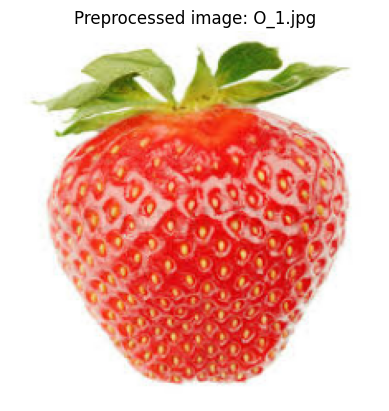

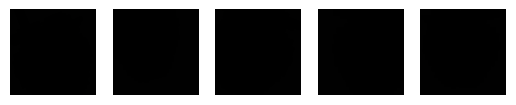

Found 34773 images belonging to 5 classes.
Images shape: (32, 224, 224, 3)
Labels shape: (32, 5)


In [3]:
# 2‑A  IMPORTS ────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up image size for all images to be resized to (e.g., 224x224 for CNNs)
IMG_SIZE = (224, 224)
IMG_EXTS = {'.jpg', '.jpeg', '.png'}  # Set of acceptable image extensions

# Convert TRAIN_DIR to Path object
TRAIN_DIR = Path(r"D:\NNDL\Dataset\DATASET\TRAIN")  # Make sure it's a Path object

# 2‑B  RESIZING & NORMALIZATION FUNCTION ─────────────────────────────────────
def preprocess_image(img_path, img_size=IMG_SIZE):
    """Load and preprocess image: resize and normalize."""
    img = tf.io.read_file(str(img_path))  # Load image (convert Path to string)
    img = tf.image.decode_jpeg(img, channels=3)  # Decode as RGB
    img = tf.image.resize(img, img_size)  # Resize to desired shape
    img = img / 255.0  # Normalize to [0, 1]
    return img

# Test the preprocessing
img_path = list(iter_images(TRAIN_DIR))[0]  # Grab a sample image
img = preprocess_image(img_path)
plt.imshow(img)
plt.title(f"Preprocessed image: {img_path.name}")
plt.axis('off')
plt.show()

# 2‑C  IMAGE AUGMENTATION (using Keras' ImageDataGenerator)
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Rescale image values to [0, 1]
    rotation_range=40,  # Random rotations
    width_shift_range=0.2,  # Horizontal shifts
    height_shift_range=0.2,  # Vertical shifts
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Zoom in/out
    horizontal_flip=True,  # Random horizontal flips
    fill_mode="nearest"  # Pixel value filling strategy
)

# Example: Apply augmentation on one image
sample_img = preprocess_image(list(iter_images(TRAIN_DIR))[0])  # Preprocess sample
sample_img = np.expand_dims(sample_img, axis=0)  # Add batch dimension
augmented_images = train_datagen.flow(sample_img, batch_size=1)

# Visualize augmented images
for i in range(5):  # Display 5 augmented images
    augmented_img = next(augmented_images)[0]  # Use next() instead of .next()
    plt.subplot(1, 5, i+1)
    plt.imshow(augmented_img)
    plt.axis('off')
plt.show()

# 2‑D  SET UP IMAGE LOADING WITH AUGMENTATION FOR TRAINING
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,  # Training directory
    target_size=IMG_SIZE,  # Resize all images to IMG_SIZE
    batch_size=32,  # Number of images per batch
    class_mode='categorical',  # Categorical labels (for multi-class classification)
    shuffle=True  # Shuffle data for randomness
)

# Display some sample data
for i, (imgs, labels) in enumerate(train_generator):
    if i == 0:  # Show the first batch
        print(f"Images shape: {imgs.shape}")
        print(f"Labels shape: {labels.shape}")
        break


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.15

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,                  # Make sure TRAIN_DIR is defined
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


Found 29559 images belonging to 5 classes.


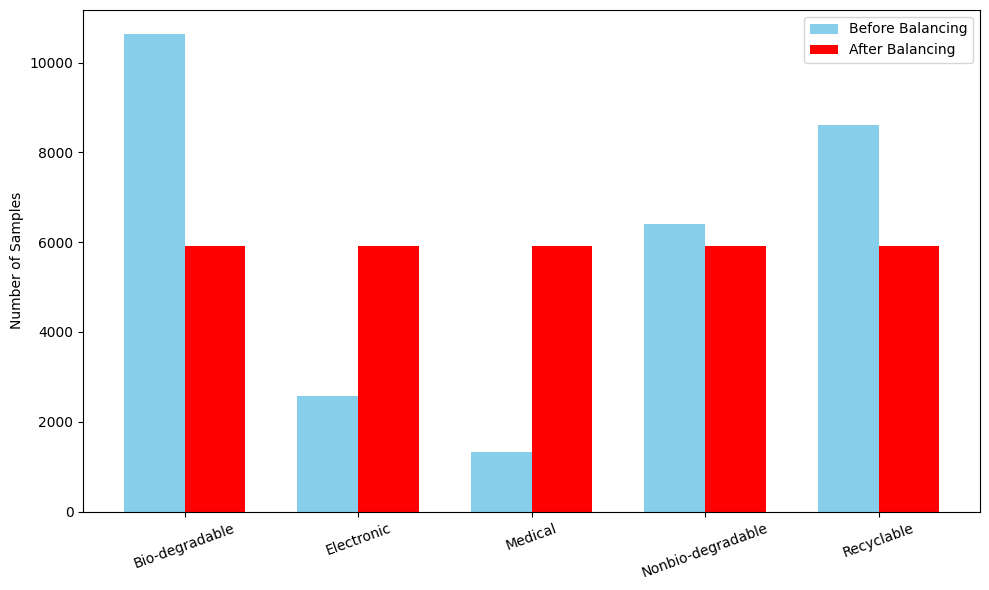

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# -------- BEFORE Balancing --------
before_counts = dict(Counter(train_gen.classes))
before_labels = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
before_values = [before_counts[i] for i in range(len(before_labels))]

# -------- AFTER Balancing (virtual using class_weight adjustment) --------
# We'll scale all classes to have the average sample count for visual representation
avg_count = int(sum(before_values) / len(before_values))
after_values = [avg_count for _ in before_values]

# -------- Plotting --------
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = range(len(before_labels))

plt.bar(x, before_values, width=bar_width, label='Before Balancing', color='skyblue')
plt.bar([p + bar_width for p in x], after_values, width=bar_width, label='After Balancing', color='red')

plt.xticks([p + bar_width/2 for p in x], before_labels, rotation=20)
plt.ylabel('Number of Samples')
# plt.title('Class Distribution Before and After Balancing')
plt.legend()
plt.tight_layout()
plt.savefig("class_distribution_balance.png", dpi=300)
plt.show()


In [13]:
batch = next(augmented_images)[0]          # shape (224,224,3)
print(batch.min(), batch.max())            # should be floats 0‑1


1.5921683e-05 0.003921569


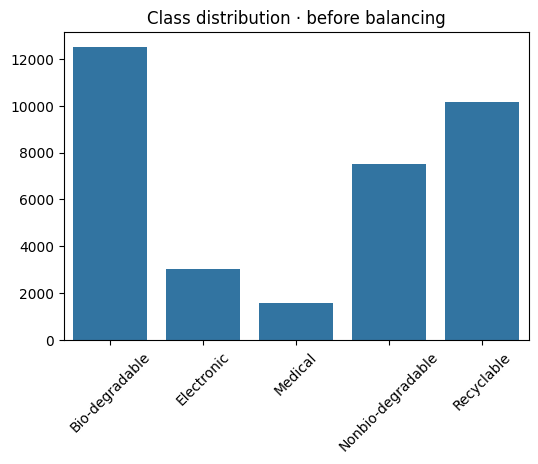

In [14]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class again (uses iter_images from Step 1)
class_names  = sorted(train_generator.class_indices, key=train_generator.class_indices.get)
train_counts = Counter(train_generator.classes)        # e.g. {0: 9200, 1: 4300, ...}

# Bar‑chart: before balancing
plt.figure(figsize=(6,4))
sns.barplot(x=class_names, y=[train_counts[i] for i in range(len(class_names))])
plt.title("Class distribution · before balancing"); plt.xticks(rotation=45); plt.show()


In [15]:
# Inverse‑frequency weighting
total        = sum(train_counts.values())
class_weight = {
    cls_idx: total / (len(class_names) * count)
    for cls_idx, count in train_counts.items()
}

print("class_weight =", class_weight)


class_weight = {np.int32(0): 0.5555679821057677, np.int32(1): 2.3059018567639256, np.int32(2): 4.435331632653061, np.int32(3): 0.9238310308182784, np.int32(4): 0.6856551316178645}


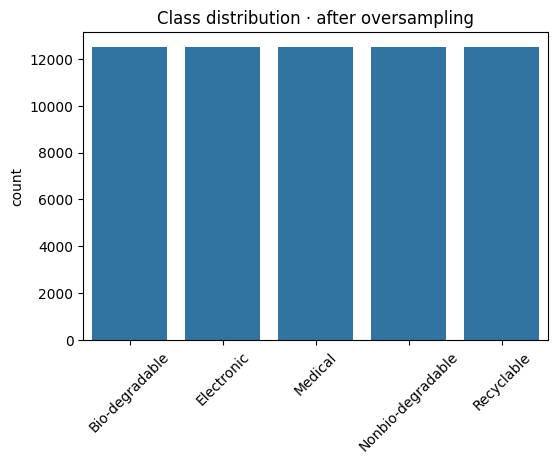

In [16]:
# Build a list of filepaths and labels with oversampling
from sklearn.utils import resample
filepaths, labels = [], []

for cls_idx, cls_name in enumerate(class_names):
    paths = [p for p in iter_images(TRAIN_DIR / cls_name)]
    max_n = max(train_counts.values())          # oversample minority classes to max_n
    paths_balanced = resample(paths, replace=True, n_samples=max_n, random_state=42)
    filepaths.extend(paths_balanced)
    labels.extend([cls_idx] * max_n)

# Quick visual check
plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title("Class distribution · after oversampling")
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45); plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7240\3333084417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


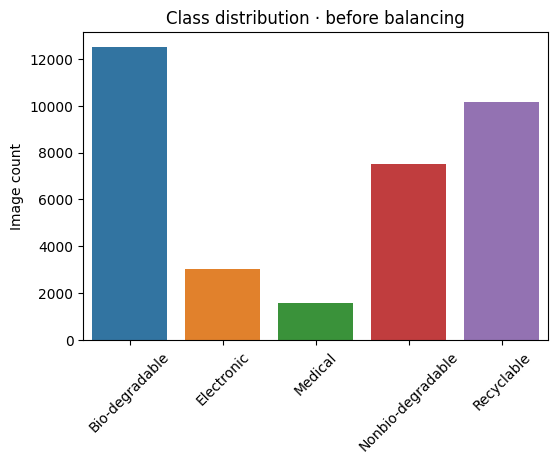

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=class_names,
    y=[train_counts[i] for i in range(len(class_names))],
    palette="tab10"          # <─ any named seaborn palette
)
plt.title("Class distribution · before balancing")
plt.xticks(rotation=45)
plt.ylabel("Image count")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7240\3328898701.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette=palette)


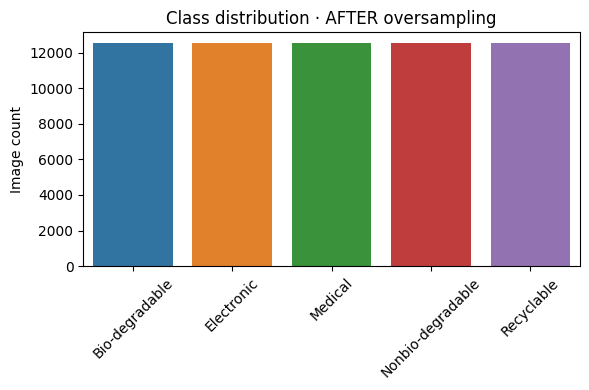

In [18]:
# Build once if you skipped it
from sklearn.utils import resample
filepaths, labels = [], []
max_n = max(train_counts.values())

for cls_idx, cls_name in enumerate(class_names):
    paths = [p for p in iter_images(TRAIN_DIR/cls_name)]
    paths_bal = resample(paths, replace=True, n_samples=max_n, random_state=42)
    filepaths.extend(paths_bal)
    labels.extend([cls_idx]*max_n)
palette = sns.color_palette("tab10", n_colors=len(class_names))

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x=labels, palette=palette)
plt.title("Class distribution · AFTER oversampling")
plt.ylabel("Image count")
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout(); plt.show()


In [8]:
# ---------- 4‑A. data generators with validation_split ----------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.15

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,  width_shift_range=0.2,  height_shift_range=0.2,
    shear_range=0.2,    zoom_range=0.2,         horizontal_flip=True,
    validation_split=VAL_SPLIT
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

num_classes = train_gen.num_classes


Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.


In [9]:
from tensorflow.keras import layers, models

def build_baseline(input_shape=(224,224,3), n_classes=5):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        layers.MaxPool2D(),
        
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPool2D(),
        
        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPool2D(),
        
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])
    return model

model = build_baseline(n_classes=num_classes)
model.summary()


D:\NNDL\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss"
)


In [19]:
EPOCHS = 5

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight,   # ← balances classes
    callbacks=[early_stop]
)


D:\NNDL\dl_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
924/924 ━━━━━━━━━━━━━━━━━━━━ 1051s 1s/step - accuracy: 0.5485 - loss: 1.1153 - val_accuracy: 0.5531 - val_loss: 1.1514
Epoch 2/5
924/924 ━━━━━━━━━━━━━━━━━━━━ 972s 1s/step - accuracy: 0.6763 - loss: 0.7283 - val_accuracy: 0.5946 - val_loss: 0.9942
Epoch 3/5
924/924 ━━━━━━━━━━━━━━━━━━━━ 921s 997ms/step - accuracy: 0.6887 - loss: 0.6980 - val_accuracy: 0.5944 - val_loss: 0.9812
Epoch 4/5
924/924 ━━━━━━━━━━━━━━━━━━━━ 925s 1s/step - accuracy: 0.7087 - loss: 0.6593 - val_accuracy: 0.5932 - val_loss: 0.9692
Epoch 5/5
924/924 ━━━━━━━━━━━━━━━━━━━━ 988s 1s/step - accuracy: 0.7196 - loss: 0.6337 - val_accuracy: 0.6300 - val_loss: 0.8906


In [20]:
import pandas as pd

baseline_metrics = pd.DataFrame(history.history)
print(baseline_metrics.tail(1))


   accuracy      loss  val_accuracy  val_loss
4  0.725397  0.619526      0.630035  0.890555


In [21]:
# Save the entire model (architecture + weights)
model.save('baseline_cnn_model.h5')

# If you want to save only the weights (if you're planning to reload only weights later):
# model.save_weights('baseline_cnn_weights.h5')


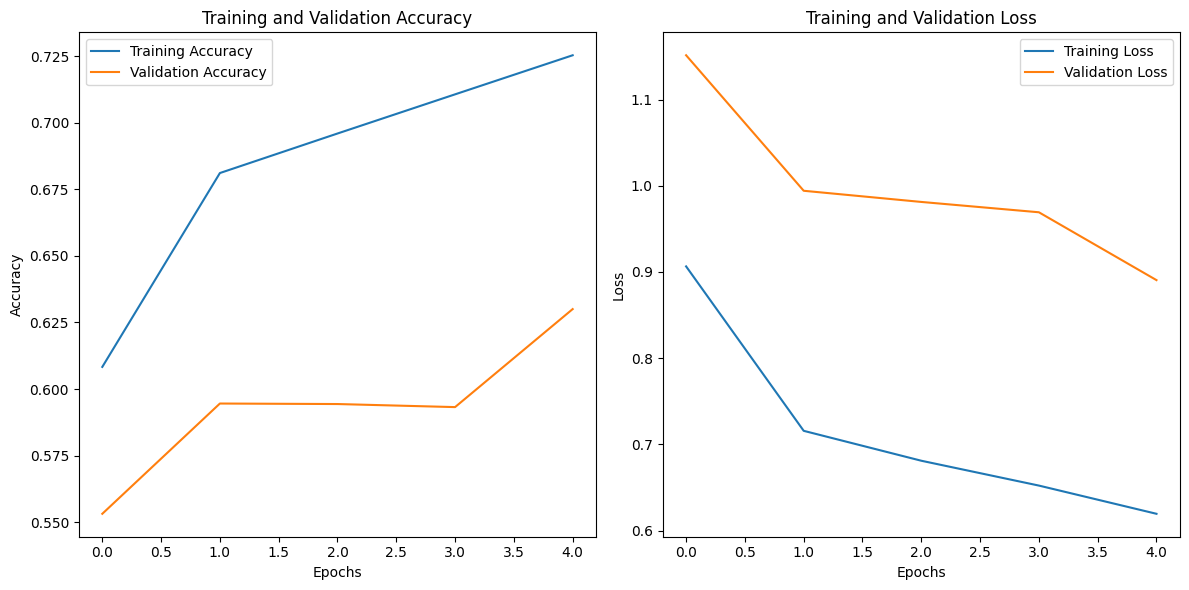

In [22]:
import matplotlib.pyplot as plt

# Plotting the training & validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 438ms/step


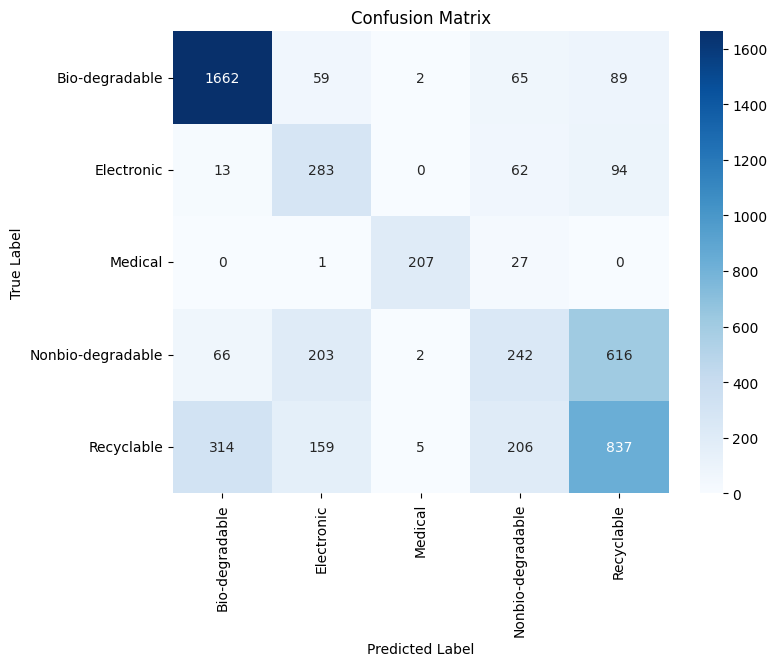

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions on validation data
val_preds = model.predict(val_gen, verbose=1)
val_preds = np.argmax(val_preds, axis=1)

# Get true labels
true_labels = val_gen.classes

# Confusion matrix
cm = confusion_matrix(true_labels, val_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_gen.class_indices.keys(), yticklabels=val_gen.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [28]:
# ─────────────────────────────────────────────────────────────
#  SAVE ALL REQUIRED FIGURES  ·  just run this one cell
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix

save_dir = Path("figures")
save_dir.mkdir(exist_ok=True)

# ---------- 1. Class counts BEFORE balancing ----------
palette = sns.color_palette("tab10", n_colors=len(class_names))
plt.figure(figsize=(6,4))
sns.barplot(x=class_names,
            y=[train_counts[i] for i in range(len(class_names))],
            palette=palette)
plt.title("Class distribution · BEFORE balancing")
plt.ylabel("Image count"); plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(save_dir / "class_counts_before.png", dpi=300)
plt.close()

# ---------- 2. Class counts AFTER oversampling ----------
plt.figure(figsize=(6,4))
sns.countplot(x=labels, palette=palette)
plt.title("Class distribution · AFTER oversampling")
plt.ylabel("Image count")
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.savefig(save_dir / "class_counts_after.png", dpi=300)
plt.close()

# ---------- 3. Accuracy & Loss curves ----------
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig(save_dir / "acc_loss_curves.png", dpi=300)
plt.close()

# ---------- 4. Confusion matrix ----------
val_preds = np.argmax(model.predict(val_gen, verbose=0), axis=1)
true_labels = val_gen.classes
cm = confusion_matrix(true_labels, val_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(save_dir / "confusion_matrix.png", dpi=300)
plt.close()

print(f"✅  Saved all figures in: {save_dir.resolve()}")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7240\1436606383.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_7240\1436606383.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette=palette)


✅  Saved all figures in: D:\NNDL\figures


In [30]:
!pip install pydot graphviz


In [32]:
np.save("history.npy", history.history)        # if history is important
np.save("class_weight.npy", class_weight)

In [1]:
from tensorflow.keras.models import load_model
model = load_model("baseline_cnn_model.h5")

import numpy as np
history_dict   = np.load("history.npy", allow_pickle=True).item()
class_weight   = np.load("class_weight.npy", allow_pickle=True).item()


In [2]:
!pip install --quiet pydot graphviz
import importlib, tensorflow.keras.utils as kutils
importlib.reload(kutils)


<module 'tensorflow.keras.utils' from 'D:\\NNDL\\dl_env\\Lib\\site-packages\\keras\\_tf_keras\\keras\\utils\\__init__.py'>

In [1]:
import shutil
print(shutil.which("dot"))   # should print full path


C:\Program Files\Graphviz\bin\dot.EXE


In [4]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="figures/baseline_cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True
)
print("✅  Saved architecture diagram to figures/baseline_cnn_architecture.png")


✅  Saved architecture diagram to figures/baseline_cnn_architecture.png


In [12]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model("checkpoints/transfer_mobilenetv2.h5")
model.summary()  # Optional: to check architecture


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,599 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [13]:
from tensorflow.keras.models import Model

# Choose the intermediate layer's name
layer_name = 'block_2_depthwise_relu'  # for example
intermediate_layer_model = Model(inputs=model.input,
                                 outputs=model.get_layer(layer_name).output)


In [16]:
import cv2
import numpy as np

# Load and preprocess the image
img_path = 'sample/Microwave_2.jpg'
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # normalize if trained that way
img = np.expand_dims(img, axis=0)


In [17]:
feature_maps = intermediate_layer_model.predict(img)
print(feature_maps.shape)  # e.g., (1, 56, 56, 144)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(1, 56, 56, 144)


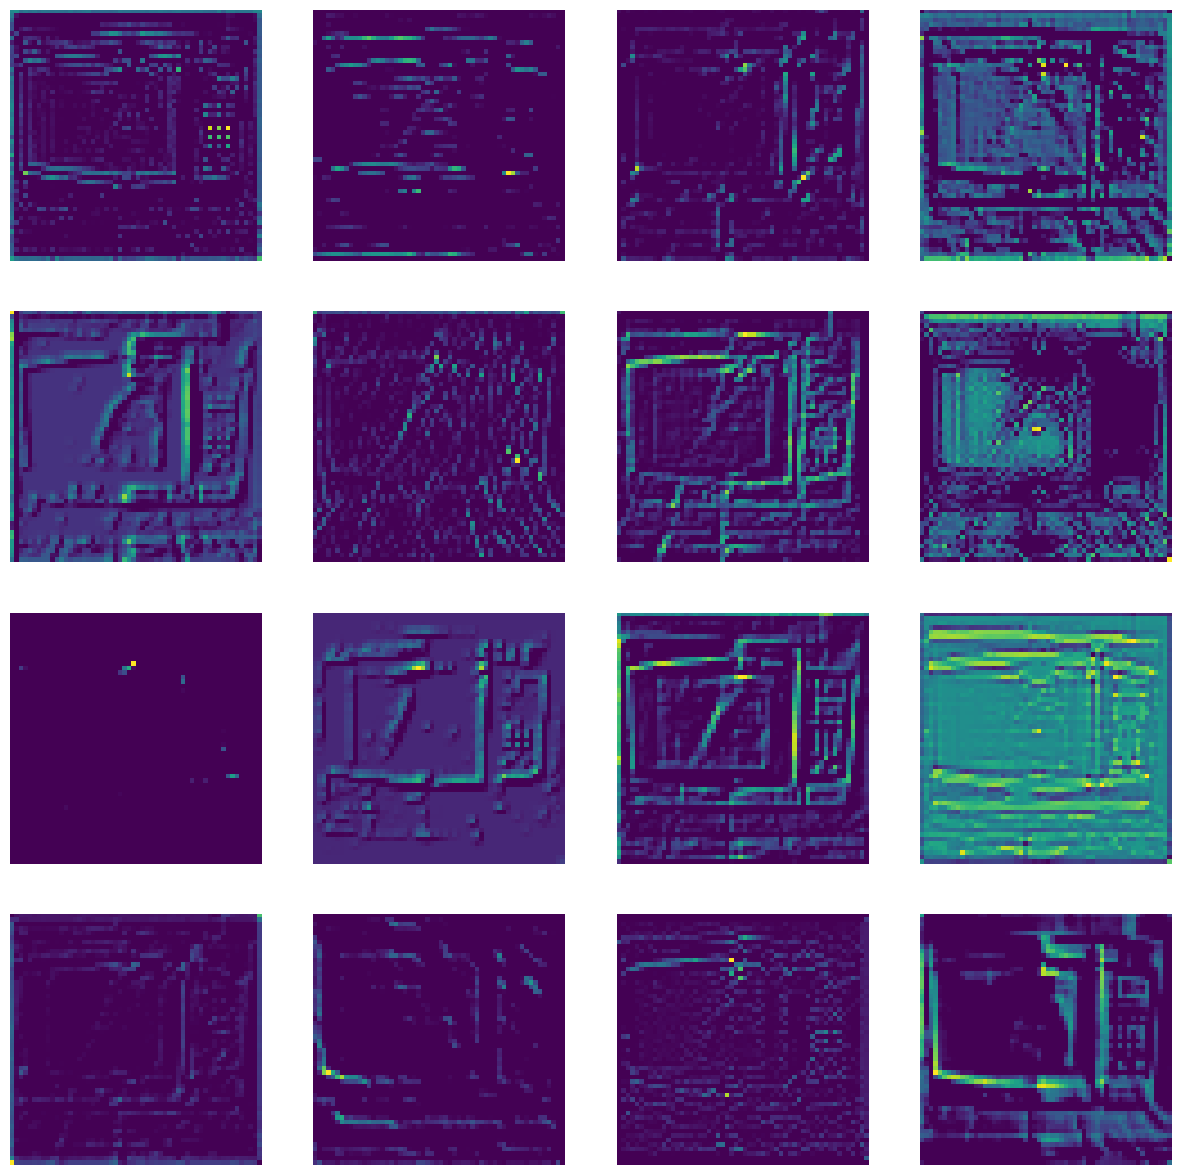

In [18]:
import matplotlib.pyplot as plt

# Plot the first 16 feature maps
num_filters = 16
plt.figure(figsize=(15, 15))
for i in range(num_filters):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.show()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,599 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

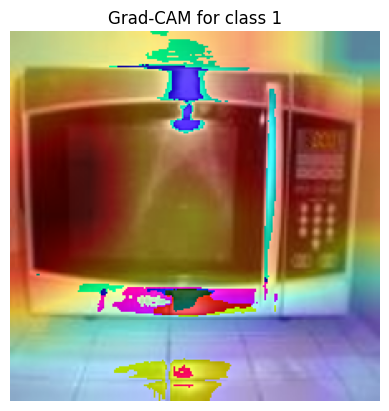

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Load model
model = load_model("checkpoints/transfer_mobilenetv2.h5")
model.summary()  # Optional: to see layer names

# Choose a convolutional layer for Grad-CAM (e.g., last conv layer)
target_layer = model.get_layer('Conv_1')  # or another suitable layer

# Load and preprocess image
img_path = "sample/Microwave_2.jpg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Create a model that maps input to activations and predictions
grad_model = Model(
    inputs=[model.inputs],
    outputs=[target_layer.output, model.output]
)

# Compute gradient of top predicted class w.r.t. target layer output
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    loss = predictions[:, pred_index]

# Extract gradients
grads = tape.gradient(loss, conv_outputs)

# Global Average Pooling on gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

# Apply ReLU and normalize
heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap)
heatmap = heatmap.numpy()  # Convert to NumPy array here
heatmap = cv2.resize(heatmap, (224, 224))

heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose heatmap on original image
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224, 224))
superimposed_img = heatmap * 0.4 + original_img

# Display result
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title(f'Grad-CAM for class {pred_index.numpy()}')
plt.axis('off')
plt.show()


In [28]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,599 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [30]:
last_conv_layer = model.get_layer('Conv_1')


In [31]:
print(last_conv_layer)

<Conv2D name=Conv_1, built=True>
